<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/HierarichicalClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Agglomerative Clustering**

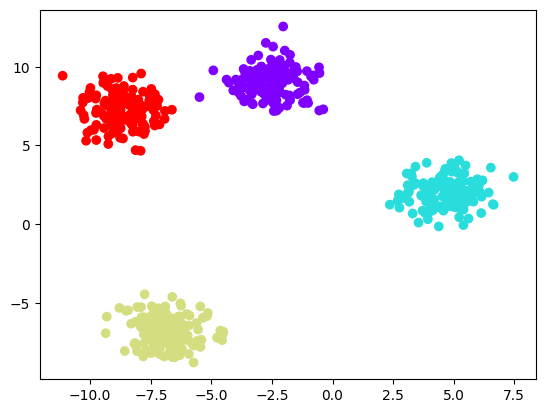

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

X , y_true = make_blobs(n_samples=600 , centers=4 , cluster_std=0.92 , random_state=42)

df = pd.DataFrame(X , columns=['Feature1' , 'Feature2'])

df['True_Label'] = y_true

plt.scatter(df['Feature1'] , df['Feature2'] , c=df['True_Label'] , cmap='rainbow')
plt.show()



In [13]:
features = df[['Feature1' , 'Feature2']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features , columns=['Feature1' , 'Feature2'])
scaled_features

array([[-0.81315913, -1.75170327],
       [-0.62611552, -1.51839243],
       [-0.38259554, -1.41793649],
       ...,
       [ 0.06585704,  1.00115463],
       [-0.93723247,  0.48032742],
       [ 0.01381464,  0.93908046]])

In [14]:
model = AgglomerativeClustering(n_clusters=4 , metric='euclidean' , linkage='ward')
y_pred = model.fit_predict(scaled_features)
y_pred


array([1, 1, 1, 1, 0, 0, 1, 3, 1, 1, 3, 0, 2, 2, 3, 3, 0, 2, 0, 0, 3, 2,
       1, 3, 2, 0, 1, 0, 0, 1, 1, 1, 3, 0, 0, 2, 3, 0, 2, 3, 0, 0, 0, 1,
       1, 2, 3, 2, 3, 0, 0, 2, 2, 3, 0, 3, 1, 0, 3, 1, 3, 1, 1, 2, 3, 0,
       3, 2, 2, 2, 3, 1, 0, 1, 2, 2, 0, 2, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2,
       2, 2, 3, 2, 1, 3, 3, 0, 1, 2, 2, 3, 1, 3, 3, 2, 3, 2, 1, 3, 0, 0,
       2, 2, 3, 3, 2, 1, 1, 2, 0, 2, 3, 3, 3, 1, 2, 3, 1, 2, 1, 0, 3, 2,
       3, 0, 0, 1, 1, 0, 1, 1, 3, 1, 3, 0, 3, 2, 2, 2, 2, 3, 0, 3, 1, 2,
       1, 1, 0, 2, 2, 3, 0, 3, 3, 2, 3, 0, 0, 2, 3, 3, 0, 2, 2, 3, 0, 2,
       2, 0, 1, 2, 3, 3, 2, 1, 3, 0, 3, 2, 0, 1, 1, 2, 3, 0, 1, 3, 0, 0,
       0, 0, 2, 1, 0, 0, 2, 2, 2, 3, 1, 0, 0, 3, 0, 0, 2, 1, 0, 0, 3, 2,
       3, 1, 0, 3, 3, 2, 2, 2, 1, 3, 3, 2, 3, 3, 1, 1, 0, 2, 1, 3, 3, 0,
       0, 1, 3, 1, 3, 2, 2, 0, 1, 0, 0, 1, 0, 2, 1, 3, 0, 0, 3, 2, 1, 1,
       1, 0, 3, 3, 0, 3, 0, 0, 3, 1, 1, 2, 3, 1, 0, 1, 3, 1, 3, 3, 1, 1,
       0, 0, 2, 0, 0, 0, 0, 1, 1, 2, 1, 3, 3, 1, 1,

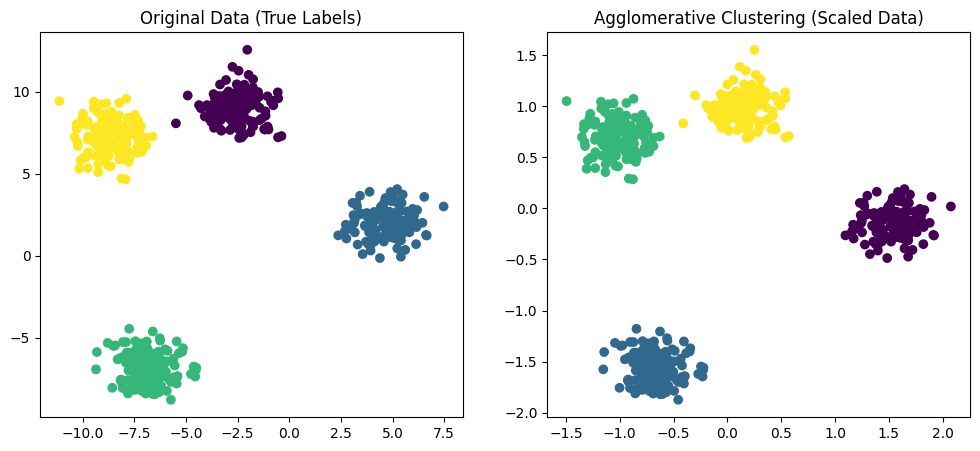

In [15]:
# Plot Original Data
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['Feature1'], df['Feature2'], c=df['True_Label'])
plt.title("Original Data (True Labels)")

# Plot Clustered Data (scaled)
plt.subplot(1, 2, 2)
plt.scatter(scaled_df['Feature1'], scaled_df['Feature2'], c=y_pred)
plt.title("Agglomerative Clustering (Scaled Data)")

plt.show()

# **Divisive Clustering**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist


In [17]:
X , y_true = make_blobs(n_samples=600 , centers=4 , random_state=42 , cluster_std=0.92)

df = pd.DataFrame(X , columns=['Feature1' , 'Feature2'])

df['True_Label'] = y_true

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)
scaled_features

array([[-0.81315913, -1.75170327,  0.4472136 ],
       [-0.62611552, -1.51839243,  0.4472136 ],
       [-0.38259554, -1.41793649,  0.4472136 ],
       ...,
       [ 0.06585704,  1.00115463, -1.34164079],
       [-0.93723247,  0.48032742,  1.34164079],
       [ 0.01381464,  0.93908046, -1.34164079]])

In [18]:
def assign_labels(X , clusters):
  labels = np.zeros(X.shape[0])

  for i , cluster in enumerate(clusters):
    for point in cluster:
      idx = np.where((X==point).all(axis=1))[0][0]
      labels[idx] = i

  return labels

In [19]:
#Method 1: Variance-based
def divisive_variance(X , K):
  clusters = [X]

  while len(clusters) < K:
    #Compute Variance
    sse_list = [np.var(cluster) if len(cluster) > 1 else 0 for cluster in clusters]
    idx = np.argmax(sse_list)
    cluster_to_split = clusters.pop(idx)

    #split using K-Means (k=2)
    kmeans = KMeans(n_clusters=2 , random_state=42)
    labels = kmeans.fit_predict(cluster_to_split)

    clusters.append(cluster_to_split[labels == 0])
    clusters.append(cluster_to_split[labels == 1])

  return assign_labels(X , clusters)

In [20]:
#Method 2: Distance-based splitting
def divisive_distance(X , K):
  clusters = [X]

  while len(clusters) < K:
    #Pick Largest Cluster
    idx = np.argmax([len(c) for c in clusters])
    cluster = clusters.pop(idx)

    #Find Farthest Point
    dist_matrix = cdist(cluster , cluster)
    i , j = np.unravel_index(np.argmax(dist_matrix) , dist_matrix.shape)

    center1 , center2 = cluster[i] , cluster[j]

    #Assign point to nearest center
    dist1 = np.linalg.norm(cluster - center1 , axis = 1)
    dist2 = np.linalg.norm(cluster - center2 , axis = 1)

    cluster1 = cluster[dist1 <= dist2]
    cluster2 = cluster[dist1 > dist2]

    clusters.append(cluster1)
    clusters.append(cluster2)

  return assign_labels(X , clusters)

In [21]:
#Method 3: Bisecting k-means
def divisive_kmeans(X , K):
  clusters = [X]

  while len(clusters) < K:

    #Pick cluster with highest SSE
    sse_list = []

    # Calculate SSE for each cluster
    for current_cluster in clusters:
      if len(current_cluster) > 1:
        km = KMeans(n_clusters=1 , random_state=42, n_init='auto').fit(current_cluster)
        sse_list.append(km.inertia_)
      else:
        sse_list.append(0)

    idx = np.argmax(sse_list)
    cluster_to_split = clusters.pop(idx) # Correctly pop from the clusters list

    kmeans = KMeans(n_clusters=2 , random_state=42, n_init='auto') # Corrected n_cluster to n_clusters and added n_init
    labels = kmeans.fit_predict(cluster_to_split)

    clusters.append(cluster_to_split[labels == 0])
    clusters.append(cluster_to_split[labels == 1]) # Corrected to use clusters.append

  return assign_labels(X , clusters)

In [22]:
y_var = divisive_variance(scaled_features , 4)
y_dist = divisive_distance(scaled_features , 4)
y_kmeans = divisive_kmeans(scaled_features , 4)

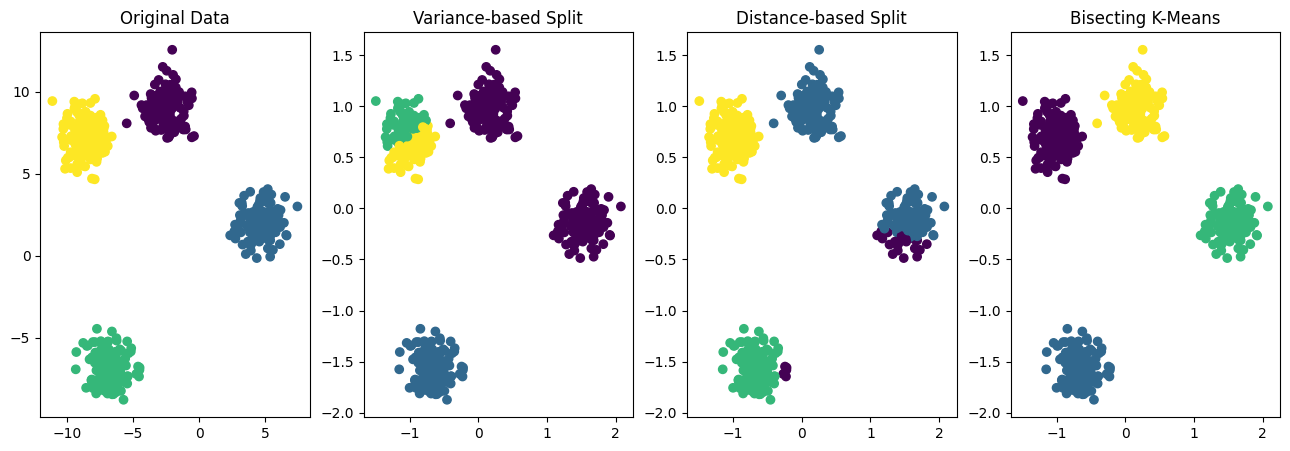

In [23]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true)
plt.title("Original Data")

plt.subplot(1, 4, 2)
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=y_var)
plt.title("Variance-based Split")

plt.subplot(1, 4, 3)
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=y_dist)
plt.title("Distance-based Split")

plt.subplot(1, 4, 4)
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=y_kmeans)
plt.title("Bisecting K-Means")

plt.show()